<a href="https://colab.research.google.com/github/pichate-k/advance-ML/blob/main/Adv_ML_week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

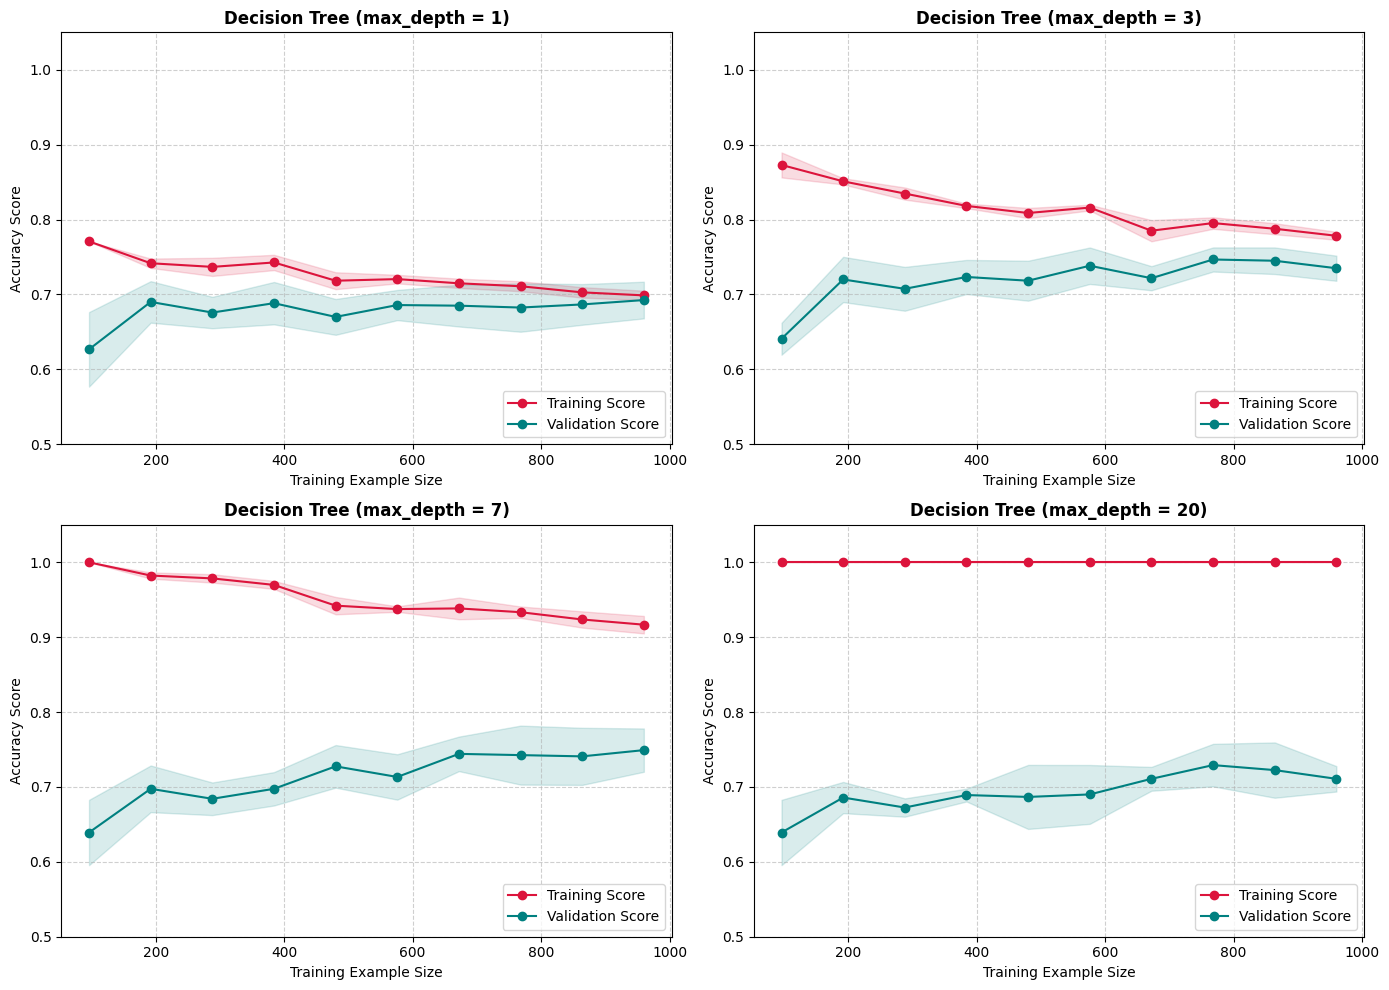

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve

# ==========================================
# 1. Generate Synthetic Dataset (มี Noise 15%)
# ==========================================
X, y = make_classification(
    n_samples=1200,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    flip_y=0.15,          # ใส่ Noise ใน Label เพื่อจำลองข้อมูลในชีวิตจริง
    random_state=42
)

# ==========================================
# 2. Setup Hyperparameters & Plot Grid
# ==========================================
depth_list = [1, 3, 7, 20]  # เปรียบเทียบความซับซ้อน 4 ระดับ
train_sizes = np.linspace(0.1, 1.0, 10)  # สุ่มสัดส่วนข้อมูลตั้งแต่ 10% ถึง 100%

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# ==========================================
# 3. Experiment Loop & Learning Curve Plotting
# ==========================================
for idx, depth in enumerate(depth_list):
    # กำหนดโมเดล
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # คำนวณ Learning Curve ด้วย 5-Fold Cross Validation
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator=clf,
        X=X, y=y,
        train_sizes=train_sizes,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    # หาค่าเฉลี่ยและค่าส่วนเบี่ยงเบนมาตรฐาน
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    # พล็อตเส้นกราฟ
    ax = axes[idx]
    ax.plot(train_sizes_abs, train_mean, 'o-', color='crimson', label='Training Score')
    ax.plot(train_sizes_abs, val_mean, 'o-', color='teal', label='Validation Score')

    # พล็อตแถบความผันผวน (Standard Deviation Range)
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='crimson')
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color='teal')

    # ตกแต่ง กราฟ
    ax.set_title(f'Decision Tree (max_depth = {depth})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Example Size', fontsize=10)
    ax.set_ylabel('Accuracy Score', fontsize=10)
    ax.set_ylim(0.5, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()